# **EDA**

**Exploratory Data Analysis , The process pf analyzing and visualizing the dataset to identify patterns, relationships before building ml models**

### **Load processed data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sales_df = pd.read_csv(
    "../data/processed/valid_sales.csv",
    dtype={"Invoice": "string"},
    parse_dates=["InvoiceDate"]
)

daily_sales = pd.read_csv(
    "../data/processed/daily_sales.csv",
    parse_dates=["Date"]
)

In [2]:
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue,Year,Month,Day,DayOfWeek,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,1,1,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,1,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,1,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,1,1,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,1,1,7,False


In [3]:
print(daily_sales)

          Date    Revenue  Quantity  Orders  Customers
0   2009-12-01   54351.23     26098     119         91
1   2009-12-02   63172.58     31804     115         94
2   2009-12-03   73972.45     49221     124        106
3   2009-12-04   40582.32     21210      89         76
4   2009-12-05    9803.05      5119      30         26
..         ...        ...       ...     ...        ...
599 2011-12-05   88620.84     44497     127        105
600 2011-12-06   56558.83     30377     115        103
601 2011-12-07   75315.55     41789     106         94
602 2011-12-08   82371.55     35010     120        105
603 2011-12-09  200918.98     93950      44         35

[604 rows x 5 columns]


In [4]:
pd.set_option("display.max_rows", None)
print(daily_sales)

          Date     Revenue  Quantity  Orders  Customers
0   2009-12-01   54351.230     26098     119         91
1   2009-12-02   63172.580     31804     115         94
2   2009-12-03   73972.450     49221     124        106
3   2009-12-04   40582.320     21210      89         76
4   2009-12-05    9803.050      5119      30         26
5   2009-12-06   24423.020     11533      74         63
6   2009-12-07   44916.210     17955     101         77
7   2009-12-08   49476.230     23143     109         91
8   2009-12-09   40265.660     17840      88         74
9   2009-12-10   44233.960     23579      92         82
10  2009-12-11   39447.890     21268      70         58
11  2009-12-13   22176.460     12517      71         63
12  2009-12-14   73174.390     45332      90         69
13  2009-12-15   50262.290     27064      98         89
14  2009-12-16   52545.550     24891      98         81
15  2009-12-17   30638.250     15413     104         77
16  2009-12-18   42470.290     17402      68    

**checking for correct values**

In [5]:
start_date = "2009-12-01"
end_date = "2009-12-31"

revenue_sum = daily_sales.loc[
    daily_sales["Date"].between(start_date,end_date),
    "Revenue"
].sum()

print("Total revenue for month ",revenue_sum)

Total revenue for month  822483.9500000001


### **Daily revenue**

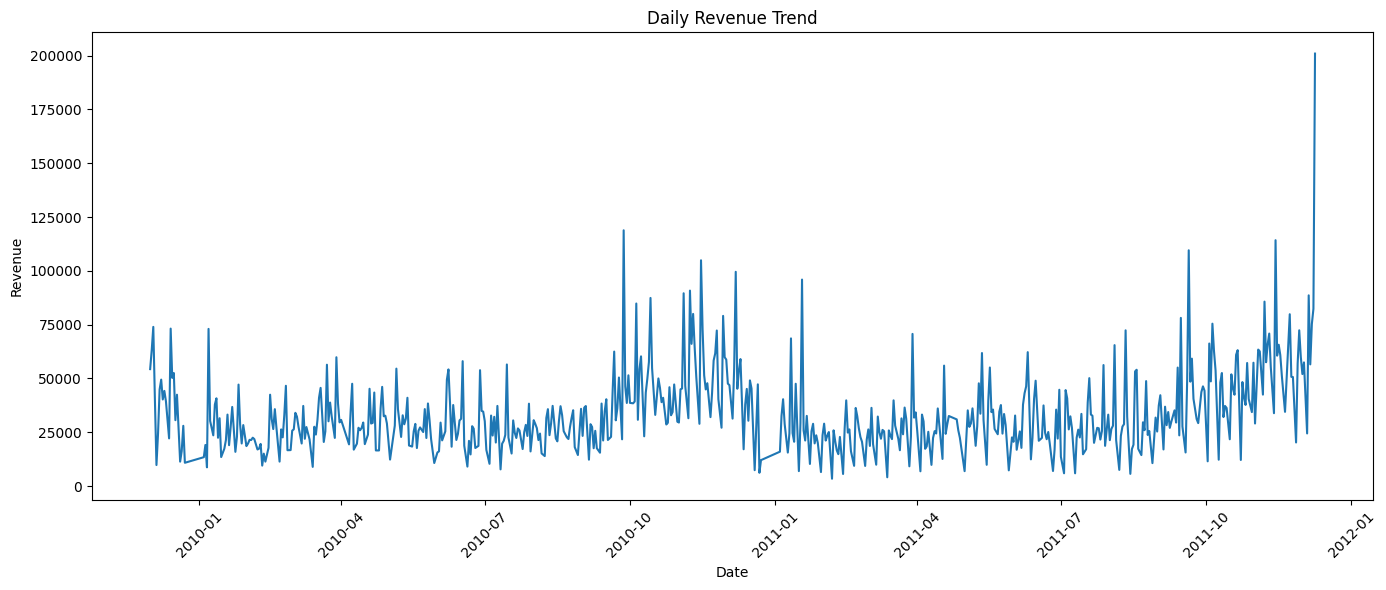

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Revenue"]
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Monthly Revenue**

In [7]:
monthly_sales = (
    sales_df
        .set_index("InvoiceDate")
        .resample("ME")["Revenue"]
        .sum()
        .reset_index()
)

monthly_sales["Month"] = monthly_sales["InvoiceDate"].dt.strftime("%Y-%m")

In [8]:
print(monthly_sales)

   InvoiceDate      Revenue    Month
0   2009-12-31   822483.950  2009-12
1   2010-01-31   651155.112  2010-01
2   2010-02-28   551504.726  2010-02
3   2010-03-31   830915.261  2010-03
4   2010-04-30   678875.252  2010-04
5   2010-05-31   657705.500  2010-05
6   2010-06-30   749537.310  2010-06
7   2010-07-31   648810.270  2010-07
8   2010-08-31   695251.910  2010-08
9   2010-09-30   921696.991  2010-09
10  2010-10-31  1161902.220  2010-10
11  2010-11-30  1464293.142  2010-11
12  2010-12-31   821452.730  2010-12
13  2011-01-31   689811.610  2011-01
14  2011-02-28   522545.560  2011-02
15  2011-03-31   716215.260  2011-03
16  2011-04-30   536968.491  2011-04
17  2011-05-31   769296.610  2011-05
18  2011-06-30   760547.010  2011-06
19  2011-07-31   718076.121  2011-07
20  2011-08-31   757841.380  2011-08
21  2011-09-30  1056435.192  2011-09
22  2011-10-31  1151263.730  2011-10
23  2011-11-30  1503866.780  2011-11
24  2011-12-31   637808.330  2011-12


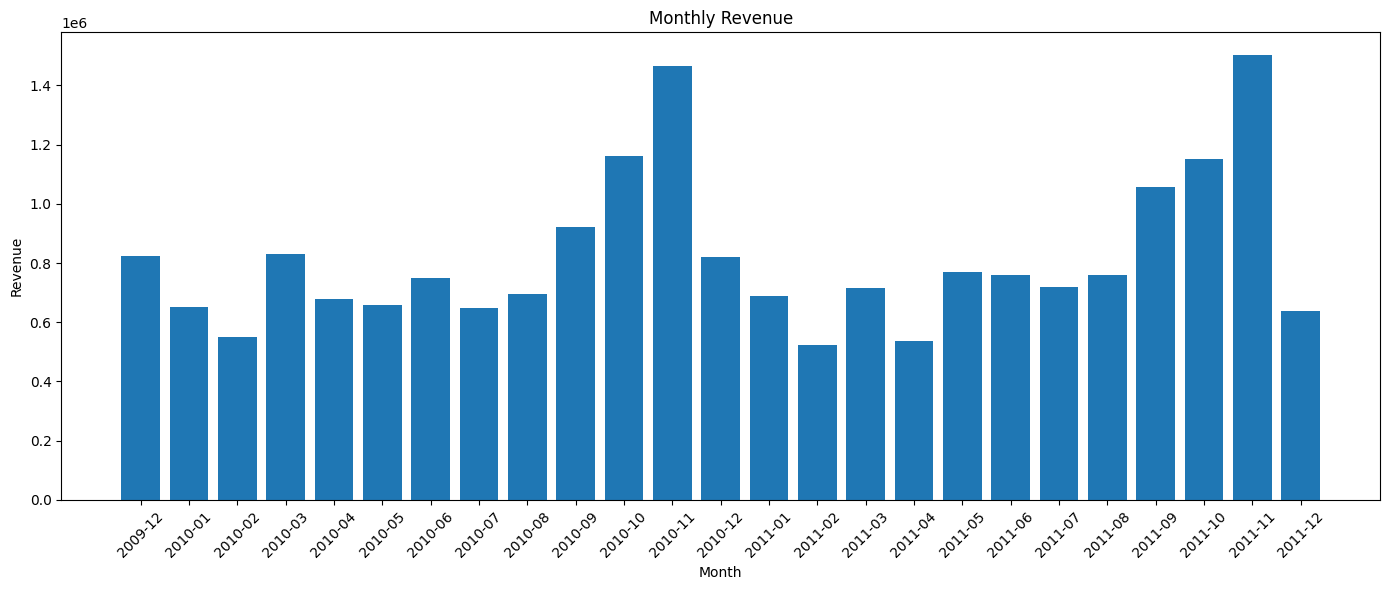

In [9]:
plt.figure(figsize=(14, 6))

plt.bar(
    monthly_sales["Month"],
    monthly_sales["Revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Top Products by revenue**

In [10]:
top_products = (
    sales_df
        .groupby("Description")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)

top_products

Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: Revenue, dtype: float64

### **Top countries**

In [11]:
country_sales = (
    sales_df
        .groupby("Country")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)

country_sales

Country
United Kingdom    1.741020e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

### **Hourly sales**

In [12]:
hourly_sales = (
    sales_df
        .groupby("Hour")["Revenue"]
        .sum()
)

hourly_sales

Hour
6           4.250
7       75765.570
8      528185.570
9     1769631.031
10    2581131.333
11    2535325.463
12    2850377.671
13    2548467.544
14    2321684.731
15    2394943.792
16    1570143.801
17     861460.132
18     273405.020
19     126830.350
20      38904.190
Name: Revenue, dtype: float64